**Bonus Question 6**

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


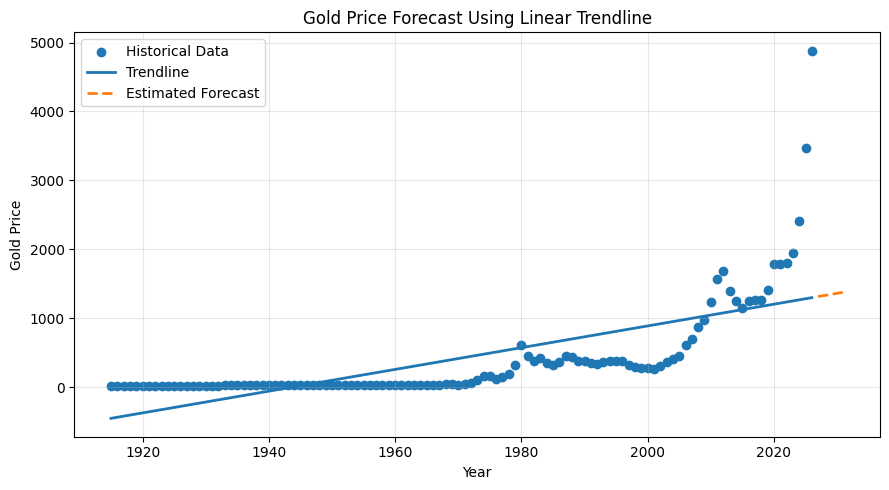

   Year  Estimated Price
0  2027          1315.28
1  2028          1331.05
2  2029          1346.82
3  2030          1362.59
4  2031          1378.36


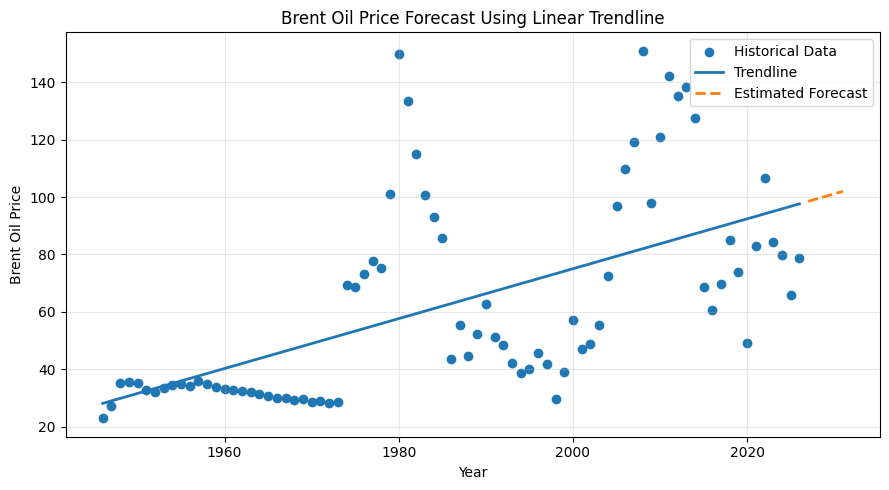

   Year  Estimated Price
0  2027            98.49
1  2028            99.36
2  2029           100.23
3  2030           101.09
4  2031           101.96


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

def forecast(file_name, commodity, output_file):
    data = pd.read_csv(file_name)

    data["Date"] = pd.to_datetime(data["Date"], dayfirst=True)
    data["Value"] = pd.to_numeric(data["Value"], errors="coerce")
    data["Year"] = data["Date"].dt.year

    annual = data.groupby("Year")["Value"].mean().reset_index()

    X = annual[["Year"]]
    y = annual["Value"]

    model = LinearRegression()
    model.fit(X, y)

    future_years = np.arange(annual["Year"].max() + 1,
                             annual["Year"].max() + 6)

    future_df = pd.DataFrame({"Year": future_years})
    predictions = model.predict(future_df)

    plt.figure(figsize=(9,5))
    plt.scatter(annual["Year"], annual["Value"],
                label="Historical Data")

    plt.plot(annual["Year"],
             model.predict(X),
             linewidth=2,
             label="Trendline")

    plt.plot(future_years,
             predictions,
             "--",
             linewidth=2,
             label="Estimated Forecast")

    plt.title(f"{commodity} Price Forecast Using Linear Trendline")
    plt.xlabel("Year")
    plt.ylabel(f"{commodity} Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_file, format="pdf", bbox_inches="tight")
    plt.show()

    forecast_table = pd.DataFrame({
        "Year": future_years,
        "Estimated Price": predictions.round(2)
    })

    forecast_table.to_csv(
        f"{commodity.replace(' ','_')}_Forecast.csv",
        index=False
    )

    print(forecast_table)

forecast("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv",
         "Gold",
         "Gold_Forecast.pdf")

forecast("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv",
         "Brent Oil",
         "Brent_Oil_Forecast.pdf")